<a href="https://colab.research.google.com/github/keshav123333/langgraph/blob/main/lecture7_parallel_workflow/lecture7_parallel_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langchain-huggingFace langgraph


In [ ]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace

llm=HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation",


    temperature=0.7
)

model=ChatHuggingFace(llm=llm)

In [ ]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict,Annotated

#parralel flow samjh ab


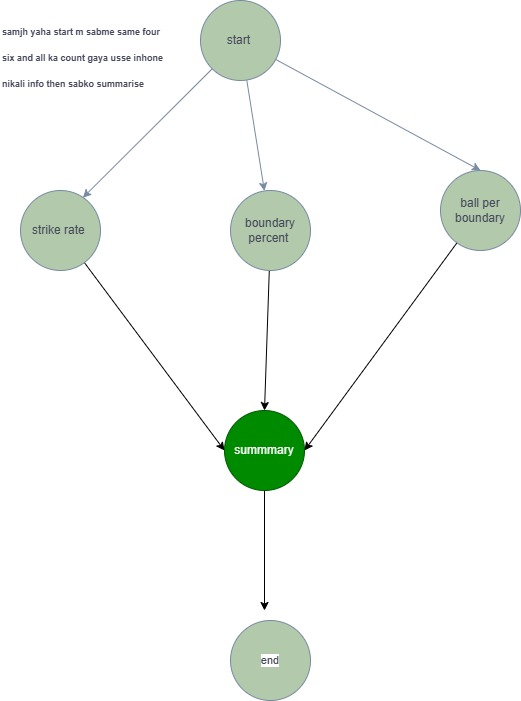

In [ ]:
class BatsmanState(TypedDict):

    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percent: float
    summary: str

In [ ]:
def calculate_sr(state: BatsmanState):

    sr = (state['runs']/state['balls'])*100

    return {'sr': sr}



def calculate_bpb(state: BatsmanState):

    bpb = state['balls']/(state['fours'] + state['sixes'])

    return {'bpb': bpb}




def calculate_boundary_percent(state: BatsmanState):

    boundary_percent = (((state['fours'] * 4) + (state['sixes'] * 6))/state['runs'])*100

    return {'boundary_percent': boundary_percent}
    #aise hi adat daal output dene ki jaise upar ecture 6 mein jaise diya
    # vo mismatch e har jagah chalta

In [ ]:
def summary(state: BatsmanState):

    summary = f"""
Strike Rate - {state['sr']} \n
Balls per boundary - {state['bpb']} \n
Boundary percent - {state['boundary_percent']}
"""

    return {'summary': summary}

In [ ]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('summary', summary)

# edges

graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percent')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundary_percent', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()

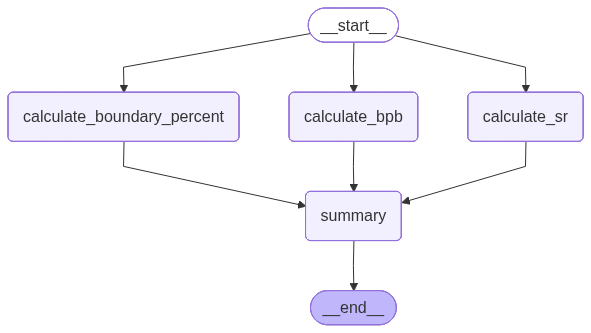

In [ ]:
workflow

In [ ]:
intial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

workflow.invoke(intial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 5.0,
 'boundary_percent': 48.0,
 'summary': '\nStrike Rate - 200.0 \n\nBalls per boundary - 5.0 \n\nBoundary percent - 48.0\n'}

#upar wale code ne error but liek chagpt se imporve toh niche wala chal gaya

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


class BatsmanState(TypedDict, total=False):  # 🔥 important (partial state allow)
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percent: float
    summary: str


# 🔹 Strike Rate
def calculate_sr(state: BatsmanState):
    runs = state.get('runs', 0)
    balls = state.get('balls', 1)

    if balls == 0:
        return {'sr': 0}

    return {'sr': (runs / balls) * 100}


# 🔹 Balls per Boundary
def calculate_bpb(state: BatsmanState):
    balls = state.get('balls', 0)
    boundaries = state.get('fours', 0) + state.get('sixes', 0)

    if boundaries == 0:
        return {'bpb': 0}

    return {'bpb': balls / boundaries}


# 🔹 Boundary %
def calculate_boundary_percent(state: BatsmanState):
    fours = state.get('fours', 0)
    sixes = state.get('sixes', 0)
    runs = state.get('runs', 1)

    if runs == 0:
        return {'boundary_percent': 0}

    return {
        'boundary_percent': (((fours * 4) + (sixes * 6)) / runs) * 100
    }


# 🔹 Summary (waits for all)
def summary(state: BatsmanState):
    return {
        'summary': f"""
Strike Rate - {state.get('sr', 0)}
Balls per boundary - {state.get('bpb', 0)}
Boundary percent - {state.get('boundary_percent', 0)}
"""
    }


# 🔥 Graph
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('summary', summary)


# ✅ PARALLEL execution
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percent')

# ✅ Fan-in (merge)
graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundary_percent', 'summary')

graph.add_edge('summary', END)


workflow = graph.compile()


# ✅ initial state
initial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}


# 🚀 run
result = workflow.invoke(initial_state)
print(result)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 200.0, 'bpb': 5.0, 'boundary_percent': 48.0, 'summary': '\nStrike Rate - 200.0\nBalls per boundary - 5.0\nBoundary percent - 48.0\n'}


# Essay workflow

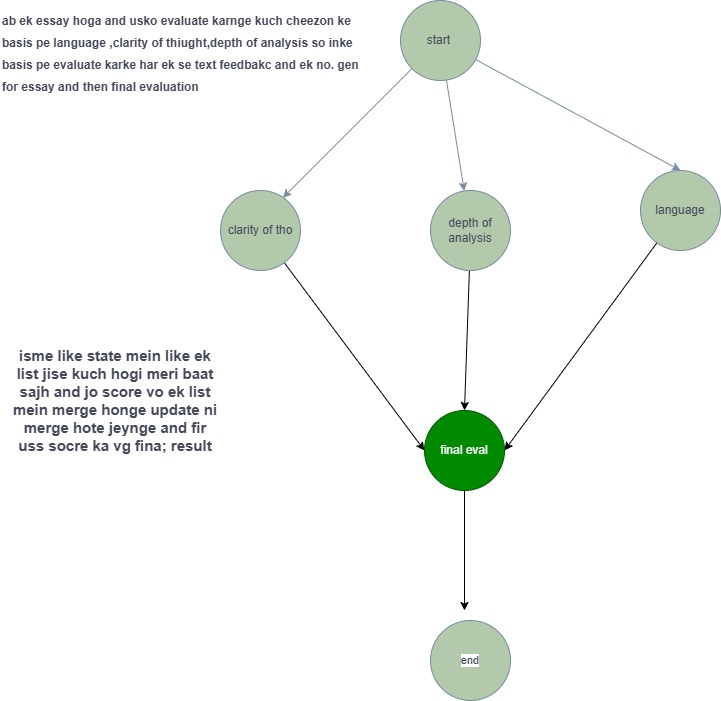

##essay workflow

In [ ]:
from langchain_core.output_parsers import PydanticOutputParser

from pydantic import BaseModel,Field
from langchain_core.prompts import PromptTemplate



#creating a model for structred output

In [ ]:
class EvaluationSchema(BaseModel):
  feedback:str=Field(description="Detailed feedback ofor the essay")
  score:int =Field(description="Score out of 10",ge=0,le=10)

In [ ]:
parser=PydanticOutputParser(pydantic_object=EvaluationSchema)

In [ ]:
template=PromptTemplate(
    template="""Generate output in this format only give feedback and score for this essay {essay}\n{format_instruction}"""
    ,input_variables=["essay"]
    ,partial_variables={"format_instruction":parser.get_format_instructions()}
)

In [ ]:
model1=template | model | parser

In [ ]:
pop=model1.invoke({"essay":"Jaipur, the capital of Rajasthan, is known as the ""Pink City"" and is a vibrant blend of rich history, stunning architecture, and modern culture. Founded in 1727 by Maharaja Sawai Jai Singh II, it was one of India’s first planned cities, designed by Vidyadhar Bhattacharya. Famous for its pastel-pink buildings, iconic landmarks like Hawa Mahal, Amber Fort, and City Palace, it serves as a UNESCO World Heritage"})

In [ ]:
print(pop.score)

7


# creating the actual project for  evealuation

In [ ]:
import operator
class EssayModel(TypedDict):
  essay :str
  language_feedback:str
  analysis_feedback:str
  clarity_feedback:str
  overall_feedback:str
  individual_score:Annotated[list[int],operator.add] #yahape add operator means maine bataya isko ki sun isme jab koi nayi list ayegi toh ye replace ni hogi
  # add hoti jaati hai
  avg_score:float

In [ ]:
def evaluate_language(state:EssayModel):
  prompt=f"Evaluate the language of this essay and score it and give feedback for this \n Essay={state.get('essay')}"
  out= model1.invoke({"essay":prompt})
  return {"language_feedback":out.feedback,'individual_score':[out.score]}  # list ke andar output.score


def evaluate_analysis(state:EssayModel):
  prompt=f"Evaluate the analysis done in this  essay like if it is done in indepth or just cover the surface level and score it and give feedback for this \n Essay= {state.get('essay')}"

  out=model1.invoke({"essay":prompt})
  return {"analysis_feedback":out.feedback,'individual_score':[out.score]}

def clartiy_of_thought(state:EssayModel):
  prompt=f"Evaluate the clarity of thoughts in  this essay and score it and give feedback for this \n  Essay={state.get('essay')}"
  out=model1.invoke({"essay":prompt})
  return {"clarity_feedback":out.feedback,'individual_score':[out.score]}

def  final_evaluation(state:EssayModel):
  prompt=f"According to this score and feedback give what is the final thoughts on my essay give a summairze feedback giving advise to improve my essay \n feedbackes are like this : \n Clarity_of_thoughts={state.get('clarity_feedback')} \n analysis_feedback = {state.get("analysis_feedback")} \n language_feedback ={state.get("language_feedback")}"
  out=model.invoke(prompt)
  return {"overall_feedback":out.content,"avg_score":sum(state.get("individual_score"))/len(state.get("individual_score"))}

In [ ]:
graph=StateGraph(EssayModel)

graph.add_node('evaluate_language',evaluate_language)
graph.add_node('evaluate_doa',evaluate_analysis)
graph.add_node('evaluate_clarity',clartiy_of_thought)
graph.add_node("final_evaluation",final_evaluation)



graph.add_edge(START,'evaluate_language')
graph.add_edge(START,"evaluate_clarity")
graph.add_edge(START,"evaluate_doa")
graph.add_edge("evaluate_language","final_evaluation")
graph.add_edge("evaluate_clarity","final_evaluation")
graph.add_edge("evaluate_doa","final_evaluation")
graph.add_edge('final_evaluation',END)

workflow=graph.compile()

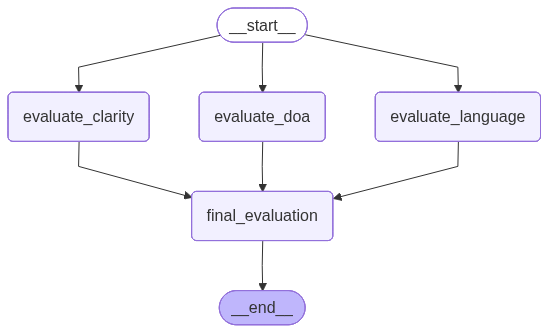

In [ ]:
input={"essay":"""Corroption is very bad thing in socity and it make evrything go wrong. Peoples do bribe and take money for doing there work which is not good habbit at all. Goverment also not always do proper action so problem become more bigger and bigger day by day.

If we want to stop corroption then we shuld do many thing like making strict law and also punish people who are doing this. But many time law also fail becuse people find other ways. Also eduction is importent but many peoples dont care about it and still do wrong work.

In last I want to say that corroption can be stoped but it is very diffcult and need many effort from all the peoples and goverment also. If we dont stop it then country will not grow proper and face many issue in future.
"""}

workflow

In [ ]:
output=workflow.invoke(input)

In [ ]:
output

{'essay': 'Corroption is very bad thing in socity and it make evrything go wrong. Peoples do bribe and take money for doing there work which is not good habbit at all. Goverment also not always do proper action so problem become more bigger and bigger day by day.\n\nIf we want to stop corroption then we shuld do many thing like making strict law and also punish people who are doing this. But many time law also fail becuse people find other ways. Also eduction is importent but many peoples dont care about it and still do wrong work.\n\nIn last I want to say that corroption can be stoped but it is very diffcult and need many effort from all the peoples and goverment also. If we dont stop it then country will not grow proper and face many issue in future.\n',
 'language_feedback': 'The essay lacks clarity and coherence. The language is simple and lacks proper grammar, vocabulary, and sentence structure. The essay also lacks specific examples and evidence to support the arguments. The writ